# A题第1-4题计算代码

本 notebook 对应 `第1-4题详细解答.md` 中的主要数值计算和图表生成。代码采用与解答文件一致的成本口径：风光度电成本、分时购电成本、余电上网收益、设备运维和合成氨装置年化投资均计入吨氨成本。

In [49]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

warnings.filterwarnings('ignore')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

# 中文可视化配置：直接加载本机 Noto CJK 字体文件，避免 Matplotlib 字体族名称回退失败。
from matplotlib import font_manager

CHINESE_FONT_PATH = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_manager.fontManager.addfont(CHINESE_FONT_PATH)
CHINESE_FONT = font_manager.FontProperties(fname=CHINESE_FONT_PATH).get_name()
plt.rcParams['font.family'] = CHINESE_FONT
plt.rcParams['font.sans-serif'] = [CHINESE_FONT]
plt.rcParams['axes.unicode_minus'] = False
print(f'当前中文绘图字体: {CHINESE_FONT}')


当前中文绘图字体: Noto Sans CJK JP


## 1. 数据录入与参数

In [50]:
load_pu = np.array([
    0.2283, 0.1833, 0.1333, 0.1650, 0.1967, 0.2717,
    0.4167, 0.5617, 0.6683, 0.7000, 0.6867, 0.6500,
    0.5433, 0.4483, 0.6050, 0.6367, 0.6250, 0.5233,
    0.4350, 0.3533, 0.3100, 0.2717, 0.2600, 0.2467,
])

wind_typ = np.array([
    0.2726, 0.3788, 0.3328, 0.3768, 0.4681, 0.2407,
    0.5701, 0.4463, 0.3582, 0.2976, 0.1934, 0.2139,
    0.3630, 0.1677, 0.2794, 0.2527, 0.1596, 0.1607,
    0.1434, 0.0938, 0.0923, 0.1220, 0.0625, 0.0798,
])

pv_typ = np.array([
    0, 0, 0, 0, 0, 0.02, 0.12, 0.28, 0.45, 0.58, 0.67, 0.70,
    0.72, 0.67, 0.58, 0.45, 0.28, 0.08, 0, 0, 0, 0, 0, 0,
])

wind_s = np.array([
    [0.2444, 0.1328, 0.2976, 0.3374, 0.2444, 0.2362],
    [0.2726, 0.2125, 0.3346, 0.3521, 0.3375, 0.2626],
    [0.3788, 0.2345, 0.3567, 0.3273, 0.3848, 0.2947],
    [0.3328, 0.2576, 0.3930, 0.5042, 0.3328, 0.2876],
    [0.3768, 0.2475, 0.3772, 0.4819, 0.3786, 0.2790],
    [0.4681, 0.2405, 0.3369, 0.5770, 0.3579, 0.2741],
    [0.2407, 0.2285, 0.3458, 0.7089, 0.4463, 0.2686],
    [0.5701, 0.1910, 0.3190, 0.6590, 0.2407, 0.2585],
    [0.4463, 0.1187, 0.2678, 0.6269, 0.5581, 0.2418],
    [0.3582, 0.1215, 0.2979, 0.5528, 0.5232, 0.1737],
    [0.2976, 0.1334, 0.2201, 0.2249, 0.3999, 0.1510],
    [0.1934, 0.1073, 0.2325, 0.1913, 0.3582, 0.1515],
    [0.2139, 0.1042, 0.2253, 0.2704, 0.3185, 0.1632],
    [0.3630, 0.1697, 0.2676, 0.2738, 0.3203, 0.1442],
    [0.1677, 0.2091, 0.2651, 0.3788, 0.2064, 0.1358],
    [0.2794, 0.2101, 0.3638, 0.5415, 0.2139, 0.1342],
    [0.2527, 0.1474, 0.3431, 0.4290, 0.3916, 0.1664],
    [0.1596, 0.1652, 0.3087, 0.4153, 0.2093, 0.2102],
    [0.1607, 0.1563, 0.3038, 0.3832, 0.1968, 0.2702],
    [0.1434, 0.1078, 0.2309, 0.2354, 0.2794, 0.2401],
    [0.0938, 0.0582, 0.1807, 0.2202, 0.2471, 0.1708],
    [0.0923, 0.0373, 0.1563, 0.1304, 0.2255, 0.2096],
    [0.1220, 0.0531, 0.1613, 0.1538, 0.1551, 0.1922],
    [0.0798, 0.0924, 0.1993, 0.2116, 0.4232, 0.2418],
])

pv_s = np.array([
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0.22, 0, 0, 0], [0.40, 0.05, 0.02, 0],
    [0.58, 0.17, 0.05, 0], [0.72, 0.28, 0.08, 0], [0.82, 0.39, 0.12, 0],
    [0.86, 0.49, 0.18, 0.02], [0.88, 0.56, 0.22, 0.08], [0.88, 0.58, 0.22, 0.12],
    [0.82, 0.50, 0.18, 0.08], [0.70, 0.40, 0.11, 0.02], [0.52, 0.30, 0.08, 0],
    [0.38, 0.15, 0.05, 0], [0.18, 0.05, 0.02, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
])

HOURS = np.arange(24)
BASE_LOAD = 6 * load_pu
WIND_CAP = 40
PV_CAP = 64
FEED_IN_PRICE = 0.3779
# Power is modeled in MW and hourly energy in MWh; price and O&M data are yuan/kWh.
KWH_PER_MWH = 1000
# Ammonia investment is interpreted as yuan per kgH2 of daily design hydrogen demand.
NH3_INVEST_YUAN_PER_KGH2 = 60000
H2_KG_PER_KG_NH3 = 0.2
KG_PER_TON = 1000
PRODUCTIONS = [72, 63, 54, 45, 36]

tou_price = np.array([
    0.8024 if (10 <= h < 15 or 18 <= h < 21)
    else 0.6074 if (7 <= h < 10 or 15 <= h < 18 or 21 <= h < 23)
    else 0.3424
    for h in HOURS
])

## 2. 通用函数

In [51]:
def split_buy_sell(total_load, wind, pv):
    gen = wind + pv
    buy = np.maximum(total_load - gen, 0)
    sell = np.maximum(gen - total_load, 0)
    return buy, sell, gen


def green_indicators(total_load, gen, buy, sell):
    e_load = total_load.sum()
    e_gen = gen.sum()
    e_buy = buy.sum()
    e_sell = sell.sum()
    self_use = (e_load - e_buy - e_sell) / e_gen
    green_ratio = (e_gen - e_sell) / e_load
    export_ratio = e_sell / e_gen
    return {
        '用电量/MWh': e_load,
        '新能源/MWh': e_gen,
        '购电/MWh': e_buy,
        '上网/MWh': e_sell,
        '自发自用占比': self_use,
        '绿电比例': green_ratio,
        '上网比例': export_ratio,
    }


def classify(ind):
    ok = [ind['自发自用占比'] > 0.6, ind['绿电比例'] > 0.3, ind['上网比例'] < 0.2]
    if all(ok):
        return '全满足'
    if not any(ok):
        return '全不满足'
    return '部分满足'


def daily_cost_72(wind, pv, buy, sell, y, ecap=0, storage_throughput=0):
    """72 t/d 扩容设备成本。y 为 0-1 负荷率数组。"""
    wind_cost = wind.sum() * KWH_PER_MWH * 0.15
    pv_cost = pv.sum() * KWH_PER_MWH * 0.12
    grid_cost = (buy * KWH_PER_MWH * tou_price).sum()
    feed_revenue = sell.sum() * KWH_PER_MWH * FEED_IN_PRICE
    alk_om = (20 * y).sum() * KWH_PER_MWH * 0.1
    pem_om = (20 * y).sum() * KWH_PER_MWH * 0.15
    nh3_om = (1.5 * y).sum() * KWH_PER_MWH * 0.002
    h2_design_kg_per_day = 72 * KG_PER_TON * H2_KG_PER_KG_NH3
    nh3_capex_daily = h2_design_kg_per_day * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    storage_capex_daily = ecap * KWH_PER_MWH * 1000 / (15 * 365)
    storage_om = 0.01 * storage_throughput * KWH_PER_MWH
    return wind_cost + pv_cost + grid_cost - feed_revenue + alk_om + pem_om + nh3_om + (nh3_capex_daily + storage_capex_daily + storage_om)


def daily_cost_36(wind, pv, buy, sell):
    """36 t/d 初始设备满负荷成本。"""
    return (
        wind.sum() * KWH_PER_MWH * 0.15
        + pv.sum() * KWH_PER_MWH * 0.12
        + (buy * KWH_PER_MWH * tou_price).sum()
        - sell.sum() * KWH_PER_MWH * FEED_IN_PRICE
        + (10 * 24) * KWH_PER_MWH * 0.1
        + (10 * 24) * KWH_PER_MWH * 0.15
        + (0.75 * 24) * KWH_PER_MWH * 0.002
        + (36 * KG_PER_TON * H2_KG_PER_KG_NH3) * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    )


def scenario_power(iw, ip):
    """iw/ip 为 0 基下标。"""
    return WIND_CAP * wind_s[:, iw], PV_CAP * pv_s[:, ip]


def row_from_result(name, production, cost, ind):
    return {
        '场景': name,
        '产量/t': production,
        '吨氨成本/元': cost / production,
        '购电/MWh': ind['购电/MWh'],
        '上网/MWh': ind['上网/MWh'],
        '自发自用占比': ind['自发自用占比'],
        '绿电比例': ind['绿电比例'],
        '上网比例': ind['上网比例'],
        '判定': classify(ind),
    }

## 3. 问题一：典型场景满负荷核算

In [52]:
wind = WIND_CAP * wind_typ
pv = PV_CAP * pv_typ
load_q1 = BASE_LOAD + 20.75
buy, sell, gen = split_buy_sell(load_q1, wind, pv)
ind_q1 = green_indicators(load_q1, gen, buy, sell)
cost_q1 = daily_cost_36(wind, pv, buy, sell)

q1_summary = pd.DataFrame([{
    **ind_q1,
    '风电/MWh': wind.sum(),
    '光伏/MWh': pv.sum(),
    '日净成本/元': cost_q1,
    '吨氨成本/元': cost_q1 / 36,
    '判定': classify(ind_q1),
}])
q1_summary

,用电量/MWh,新能源/MWh,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,风电/MWh,光伏/MWh,日净成本/元,吨氨成本/元,判定
0,558.72,603.448,172.0438,216.7718,0.281556,0.692075,0.359222,245.048,358.4,195056.216695,5418.228242,部分满足


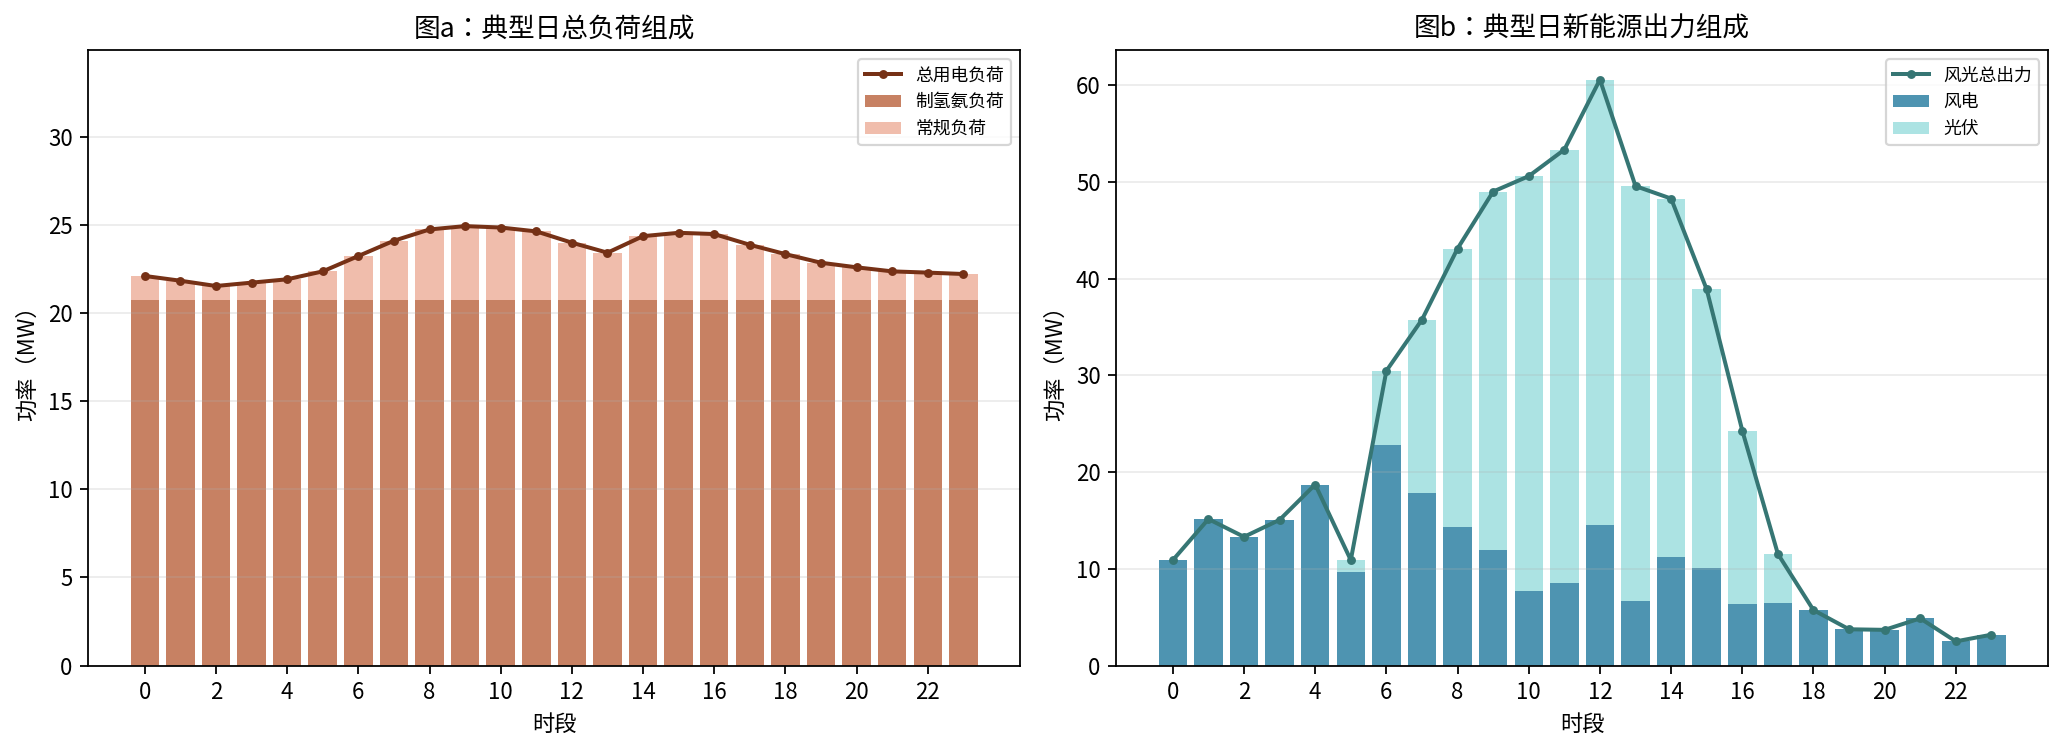

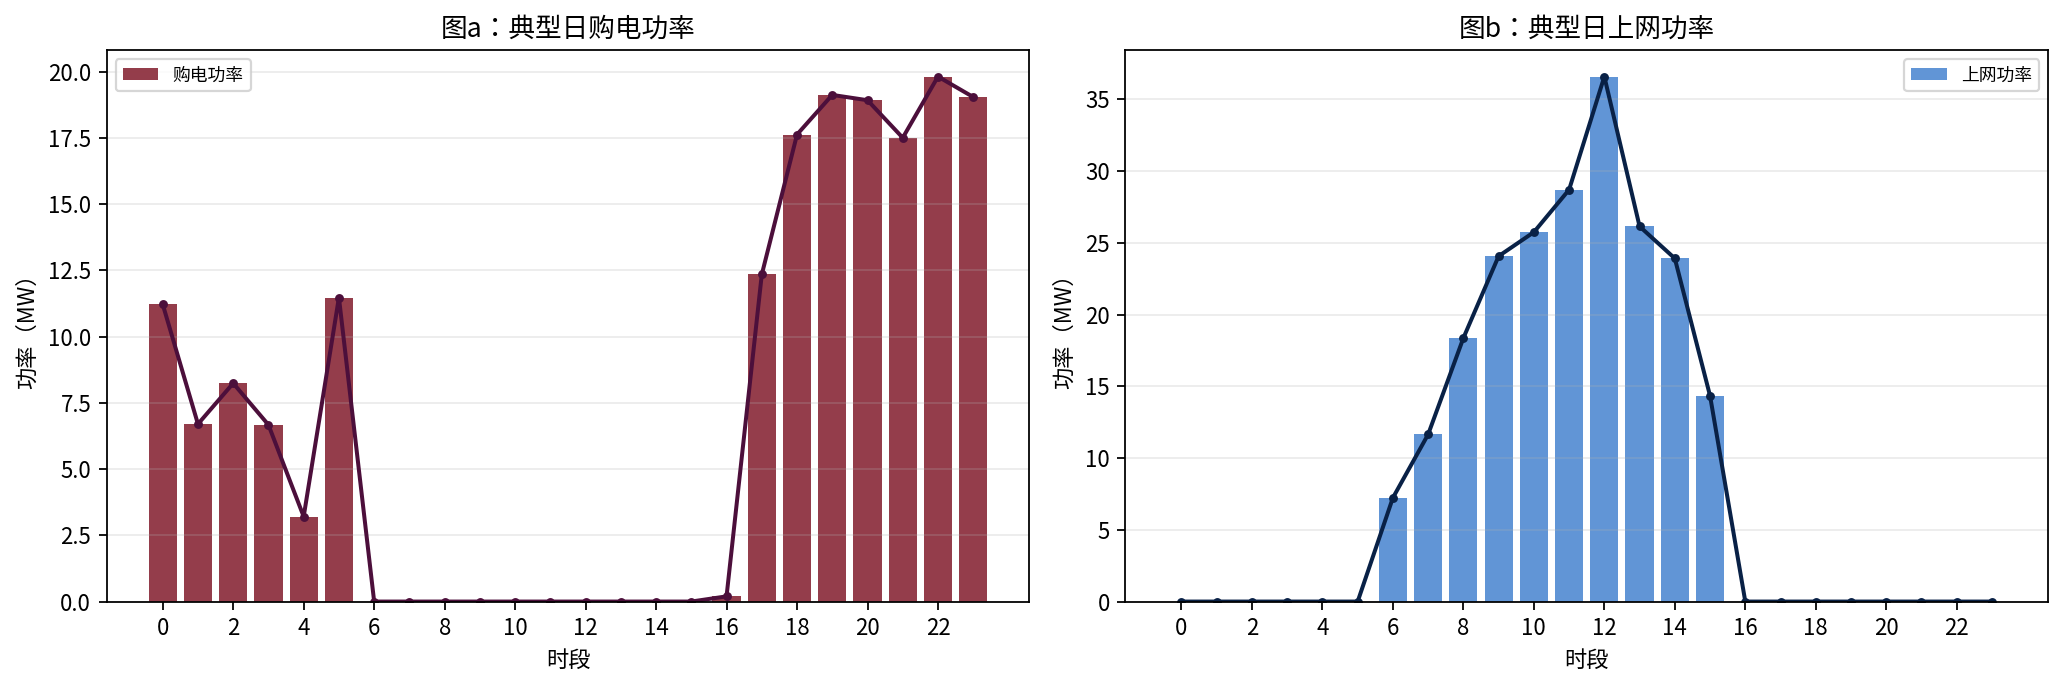

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=160)

# 总用电负荷 = 制氢氨固定负荷 + 常规负荷。
axes[0].bar(HOURS, 20.75, label='制氢氨负荷', color='#bd6b48', alpha=0.85)
axes[0].bar(HOURS, BASE_LOAD, bottom=20.75, label='常规负荷', color="#eeb29e", alpha=0.85)
axes[0].plot(HOURS, load_q1, label='总用电负荷', color="#763116", linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('图a：典型日总负荷组成')
axes[0].set_xlabel('时段')
axes[0].set_ylabel('功率（MW）')
axes[0].set_xticks(HOURS[::2])
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, load_q1.max() * 1.4)

# 新能源出力 = 风电 + 光伏。
axes[1].bar(HOURS, wind, label='风电', color="#2f81a4", alpha=0.85)
axes[1].bar(HOURS, pv, bottom=wind, label='光伏', color="#9edede", alpha=0.85)
axes[1].plot(HOURS, gen, label='风光总出力', color="#367674", linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('图b：典型日新能源出力组成')
axes[1].set_xlabel('时段')
axes[1].set_ylabel('功率（MW）')
axes[1].set_xticks(HOURS[::2])
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUT / 'q1_power_curves.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), dpi=160)

axes[0].bar(HOURS, buy, color="#892837", alpha=0.9, label='购电功率')
axes[0].plot(HOURS, buy, color="#4c0f3b", linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('图a：典型日购电功率')
axes[0].set_xlabel('时段')
axes[0].set_ylabel('功率（MW）')
axes[0].set_xticks(HOURS[::2])
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].bar(HOURS, sell, color="#508ad2", alpha=0.9, label='上网功率')
axes[1].plot(HOURS, sell, color="#092146", linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('图b：典型日上网功率')
axes[1].set_xlabel('时段')
axes[1].set_ylabel('功率（MW）')
axes[1].set_xticks(HOURS[::2])
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUT / 'q1_buy_sell_curves.png', bbox_inches='tight')
plt.show()


## 4. 问题二：离散开停优化

In [54]:
def opt_discrete(wind, pv, production):
    hours_on = int(production // 3)
    marginal = []
    for h in HOURS:
        re = wind[h] + pv[h]
        base = BASE_LOAD[h]
        c_off = tou_price[h] * max(base - re, 0) - FEED_IN_PRICE * max(re - base, 0)
        c_on = tou_price[h] * max(base + 41.5 - re, 0) - FEED_IN_PRICE * max(re - base - 41.5, 0)
        marginal.append(c_on - c_off)
    y = np.zeros(24)
    y[np.argsort(marginal)[:hours_on]] = 1
    total_load = BASE_LOAD + 41.5 * y
    buy, sell, gen = split_buy_sell(total_load, wind, pv)
    ind = green_indicators(total_load, gen, buy, sell)
    cost = daily_cost_72(wind, pv, buy, sell, y)
    return y, ind, cost


typical_q2_rows = []
for p in PRODUCTIONS:
    y, ind, cost = opt_discrete(WIND_CAP * wind_typ, PV_CAP * pv_typ, p)
    row = row_from_result('typical', p, cost, ind)
    row['开机小时'] = ','.join(map(str, np.where(y > 0)[0]))
    typical_q2_rows.append(row)

typical_q2 = pd.DataFrame(typical_q2_rows)
typical_q2

,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定,开机小时
0,typical,72,7315.029948,493.9522,40.6802,0.865174,0.532561,0.067413,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18..."
1,typical,63,6580.506289,376.0424,47.2704,0.843332,0.596616,0.078334,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,21..."
2,typical,54,6052.459948,264.1404,59.8684,0.801579,0.672980,0.099211,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,23"
3,typical,45,5697.967631,227.6840,147.9120,0.509777,0.666749,0.245111,部分满足,"0,1,2,3,4,5,6,8,9,10,11,12,13,14,23"
4,typical,36,5383.454730,225.3022,270.0302,0.105042,0.596753,0.447479,部分满足,"0,1,2,3,4,5,6,11,12,13,14,23"


In [55]:
def solve_all_scenarios_discrete():
    """Return full 5-production x 24-scenario table and per-scenario least-cost table."""
    all_rows = []
    detail = {}
    for iw in range(6):
        for ip in range(4):
            wind, pv = scenario_power(iw, ip)
            scenario_name = f'W{iw+1}P{ip+1}'
            scenario_candidates = []
            for p in PRODUCTIONS:
                y, ind, cost = opt_discrete(wind, pv, p)
                row = row_from_result(scenario_name, p, cost, ind)
                row['开机小时数'] = int(y.sum())
                row['开机小时'] = ','.join(map(str, np.where(y > 0)[0]))
                all_rows.append(row)
                scenario_candidates.append((p, y, ind, cost, row))
            detail[scenario_name] = scenario_candidates

    all_df = pd.DataFrame(all_rows)
    best_idx = all_df.groupby('场景')['吨氨成本/元'].idxmin()
    best_df = all_df.loc[best_idx].sort_values('场景').reset_index(drop=True)
    return all_df, best_df, detail


q2_all_df, q2_best_df, q2_detail = solve_all_scenarios_discrete()
q2_df = q2_best_df  # 兼容后续年度统计和成本分布图：表示每个场景的最低吨氨成本方案。
q2_best_df


,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定,开机小时数,开机小时
0,W1P1,36,4247.561664,233.2102,436.2542,-0.145379,0.582599,0.572689,部分满足,12,"0,1,2,3,4,5,6,7,8,12,14,23"
1,W1P2,36,6219.066080,262.5022,206.9862,0.177327,0.530172,0.411337,部分满足,12,"0,1,2,3,4,5,6,11,12,13,15,23"
2,W1P3,36,7902.034827,345.8904,124.6144,0.261422,0.380924,0.369289,部分满足,12,"0,1,2,3,4,5,6,7,8,9,15,23"
3,W1P4,36,8463.028605,361.2504,75.3344,0.447703,0.353432,0.276148,部分满足,12,"0,1,2,3,4,5,6,7,8,9,15,23"
4,W2P1,36,4870.111022,263.2564,363.4404,-0.103166,0.528822,0.551583,部分满足,12,"0,1,2,3,4,5,6,10,11,13,15,23"
5,W2P2,36,6896.216080,298.4522,140.0762,0.300221,0.465829,0.349890,部分满足,12,"0,1,2,3,4,5,6,12,13,14,15,23"
6,W2P3,36,8754.478161,411.9984,87.8624,0.250909,0.262603,0.374546,全不满足,12,"0,1,2,3,4,5,6,9,15,16,17,23"
7,W2P4,36,9316.939464,427.5886,38.8126,0.543231,0.234700,0.228385,全不满足,12,"0,1,2,3,4,5,6,7,15,16,17,23"
8,W3P1,36,4136.546708,223.3262,445.4462,-0.140941,0.600290,0.570471,部分满足,12,"0,1,2,3,4,5,6,10,12,13,14,23"
9,W3P2,36,6037.690400,245.1004,208.6604,0.200963,0.561318,0.399518,部分满足,12,"0,1,2,3,4,5,6,12,13,14,15,23"


In [56]:
# 问题二（2）：完整保留“每种产量 × 24场景”的离散优化结果。
q2_all_df.to_csv(OUT / 'q2_all_productions_discrete.csv', index=False, encoding='utf-8-sig')
q2_best_df.to_csv(OUT / 'q2_best_by_scenario_discrete.csv', index=False, encoding='utf-8-sig')

q2_prod_summary = (
    q2_all_df
    .groupby('产量/t')
    .agg(
        场景数=('场景', 'count'),
        平均吨氨成本=('吨氨成本/元', 'mean'),
        最小吨氨成本=('吨氨成本/元', 'min'),
        最大吨氨成本=('吨氨成本/元', 'max'),
        平均购电量=('购电/MWh', 'mean'),
        平均上网量=('上网/MWh', 'mean'),
        平均自发自用占比=('自发自用占比', 'mean'),
        平均绿电比例=('绿电比例', 'mean'),
        平均上网比例=('上网比例', 'mean'),
    )
    .reset_index()
)
q2_prod_summary.to_csv(OUT / 'q2_by_production_summary.csv', index=False, encoding='utf-8-sig')

q2_prod_class = (
    q2_all_df
    .pivot_table(index='产量/t', columns='判定', values='场景', aggfunc='count', fill_value=0)
    .reset_index()
)
for col in ['全满足', '部分满足', '全不满足']:
    if col not in q2_prod_class.columns:
        q2_prod_class[col] = 0
q2_prod_class = q2_prod_class[['产量/t', '全满足', '部分满足', '全不满足']]
q2_prod_class.to_csv(OUT / 'q2_by_production_class_counts.csv', index=False, encoding='utf-8-sig')

q2_prod_summary, q2_prod_class


(   产量/t  场景数       平均吨氨成本       最小吨氨成本        最大吨氨成本       平均购电量       平均上网量  平均自发自用占比    平均绿电比例    平均上网比例
 0    36   24  6685.603435  3562.176219   9316.939464  297.993200  215.248533  0.174941  0.466650  0.412530
 1    45   24  7043.740721  4228.797642   9457.551018  355.493042  148.248375  0.422832  0.479680  0.288584
 2    54   24  7370.842743  4673.211924   9689.300498  417.360717   85.616050  0.673999  0.483285  0.163000
 3    63   24  7775.720311  5254.921254  10049.118065  509.617025   53.372358  0.826001  0.453330  0.086999
 4    72   24  8278.560848  5986.190764  10369.134736  614.296658   33.551992  0.912556  0.418676  0.043722,
 判定  产量/t  全满足  部分满足  全不满足
 0     36    0    21     3
 1     45    1    19     4
 2     54   14     9     1
 3     63   14    10     0
 4     72   18     6     0)

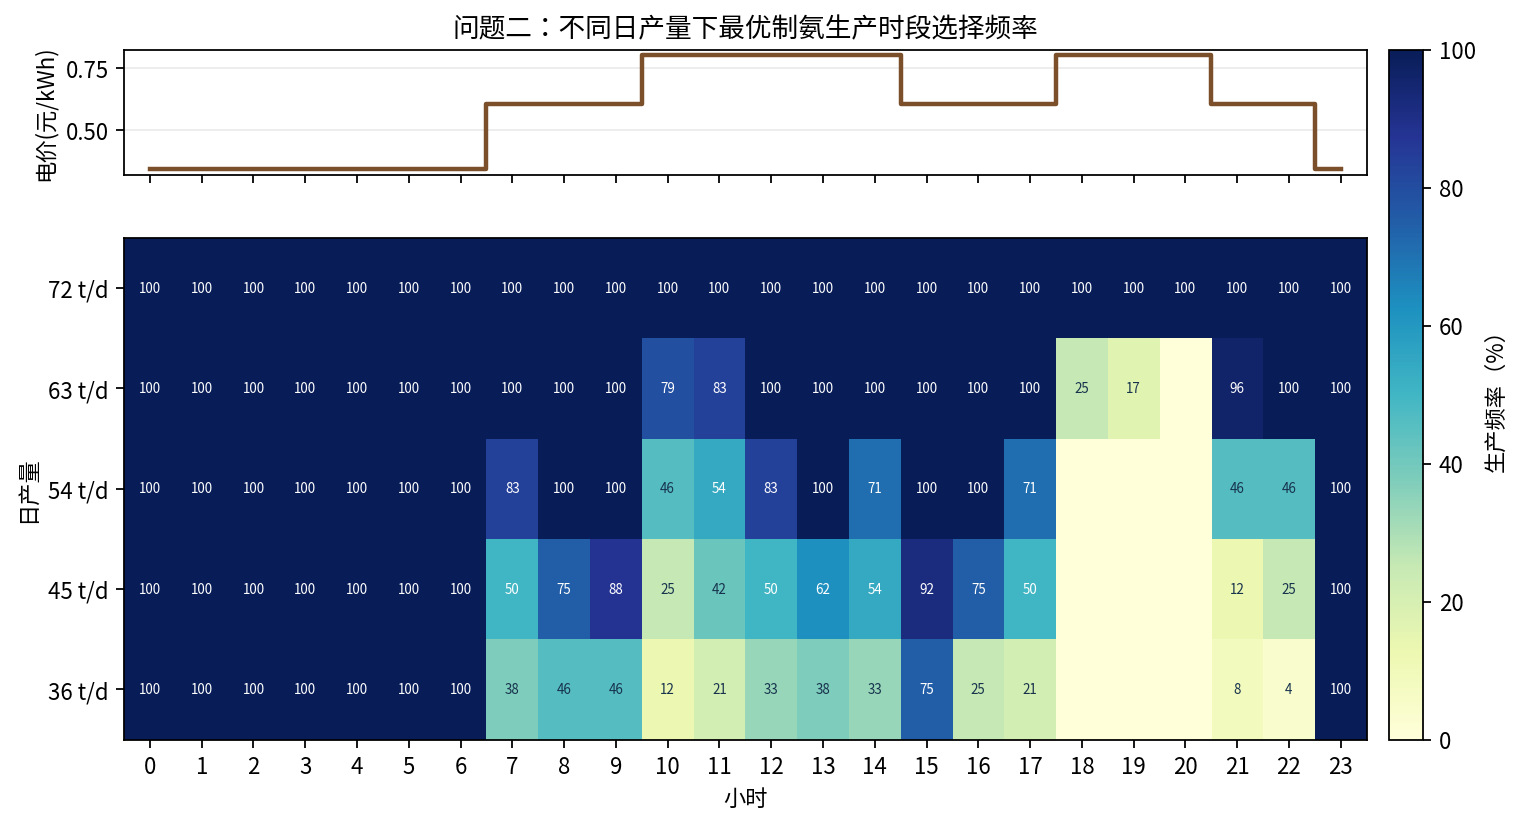

,00:00,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,...,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00
产量/t,,,,,,,,,,,,,,,,,,,,,
72,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0
63,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.0,100.000000,25.0,16.666667,0.0,95.833333,100.000000,100.0
54,100.0,100.0,100.0,100.0,100.0,100.0,100.0,83.333333,100.000000,100.000000,...,70.833333,100.000000,100.0,70.833333,0.0,0.000000,0.0,45.833333,45.833333,100.0
45,100.0,100.0,100.0,100.0,100.0,100.0,100.0,50.000000,75.000000,87.500000,...,54.166667,91.666667,75.0,50.000000,0.0,0.000000,0.0,12.500000,25.000000,100.0
36,100.0,100.0,100.0,100.0,100.0,100.0,100.0,37.500000,45.833333,45.833333,...,33.333333,75.000000,25.0,20.833333,0.0,0.000000,0.0,8.333333,4.166667,100.0


In [57]:
# 问题二（2）：最优制氨生产时段安排。颜色表示该小时在24个场景中被选为生产时段的比例。
on_freq = []
for p in PRODUCTIONS:
    ys = []
    for candidates in q2_detail.values():
        for cand_p, y, ind, cost, row in candidates:
            if cand_p == p:
                ys.append(y)
                break
    on_freq.append(np.mean(np.vstack(ys), axis=0) * 100)
on_freq = np.vstack(on_freq)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.6), dpi=160, gridspec_kw={'height_ratios': [1, 4]}, sharex=True)
axes[0].step(HOURS, tou_price, where='mid', color='#7a4f2a', linewidth=2)
axes[0].set_ylabel('电价(元/kWh)')
axes[0].set_title('问题二：不同日产量下最优制氨生产时段选择频率')
axes[0].grid(axis='y', alpha=0.25)

im = axes[1].imshow(on_freq, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
axes[1].set_yticks(np.arange(len(PRODUCTIONS)))
axes[1].set_yticklabels([f'{p} t/d' for p in PRODUCTIONS])
axes[1].set_xticks(HOURS)
axes[1].set_xlabel('小时')
axes[1].set_ylabel('日产量')
for i in range(on_freq.shape[0]):
    for h in range(on_freq.shape[1]):
        val = on_freq[i, h]
        if val >= 50:
            axes[1].text(h, i, f'{val:.0f}', ha='center', va='center', fontsize=6, color='white')
        elif val > 0:
            axes[1].text(h, i, f'{val:.0f}', ha='center', va='center', fontsize=6, color='#17324d')
cb = fig.colorbar(im, ax=axes, pad=0.015)
cb.set_label('生产频率（%）')
fig.savefig(OUT / 'q2_optimal_production_hours_heatmap.png', bbox_inches='tight')
plt.show()

q2_on_hour_frequency = pd.DataFrame(on_freq, index=PRODUCTIONS, columns=[f'{h:02d}:00' for h in HOURS])
q2_on_hour_frequency.index.name = '产量/t'
q2_on_hour_frequency.to_csv(OUT / 'q2_optimal_production_hour_frequency.csv', encoding='utf-8-sig')
q2_on_hour_frequency


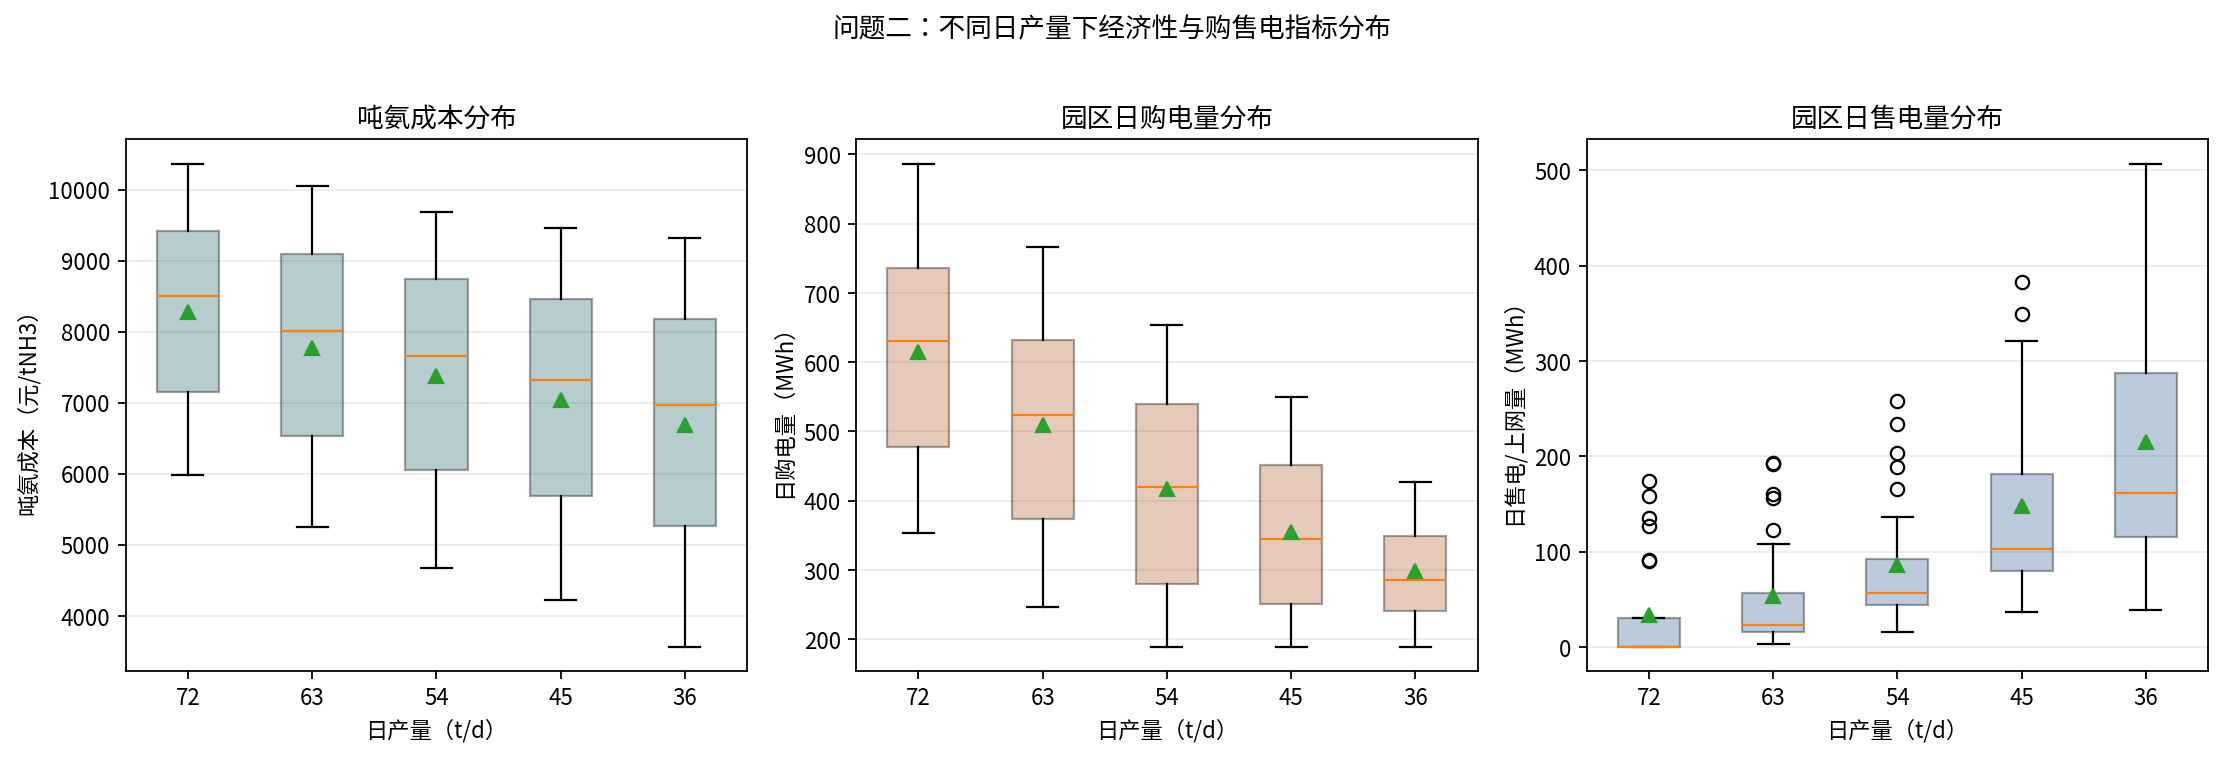

In [58]:
# 问题二（2）：吨氨成本、日购电量、日售电量在24场景下的分布。
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), dpi=160)
metrics = [
    ('吨氨成本/元', '吨氨成本（元/tNH3）', '吨氨成本分布'),
    ('购电/MWh', '日购电量（MWh）', '园区日购电量分布'),
    ('上网/MWh', '日售电/上网量（MWh）', '园区日售电量分布'),
]
colors = ['#2f6f73', '#b86938', '#3d6b99']
for ax, (col, ylabel, title), color in zip(axes, metrics, colors):
    data = [q2_all_df.loc[q2_all_df['产量/t'] == p, col].values for p in PRODUCTIONS]
    bp = ax.boxplot(data, labels=[str(p) for p in PRODUCTIONS], showmeans=True, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.set_xlabel('日产量（t/d）')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('问题二：不同日产量下经济性与购售电指标分布', y=1.02)
fig.tight_layout()
fig.savefig(OUT / 'q2_cost_buy_sell_distribution.png', bbox_inches='tight')
plt.show()


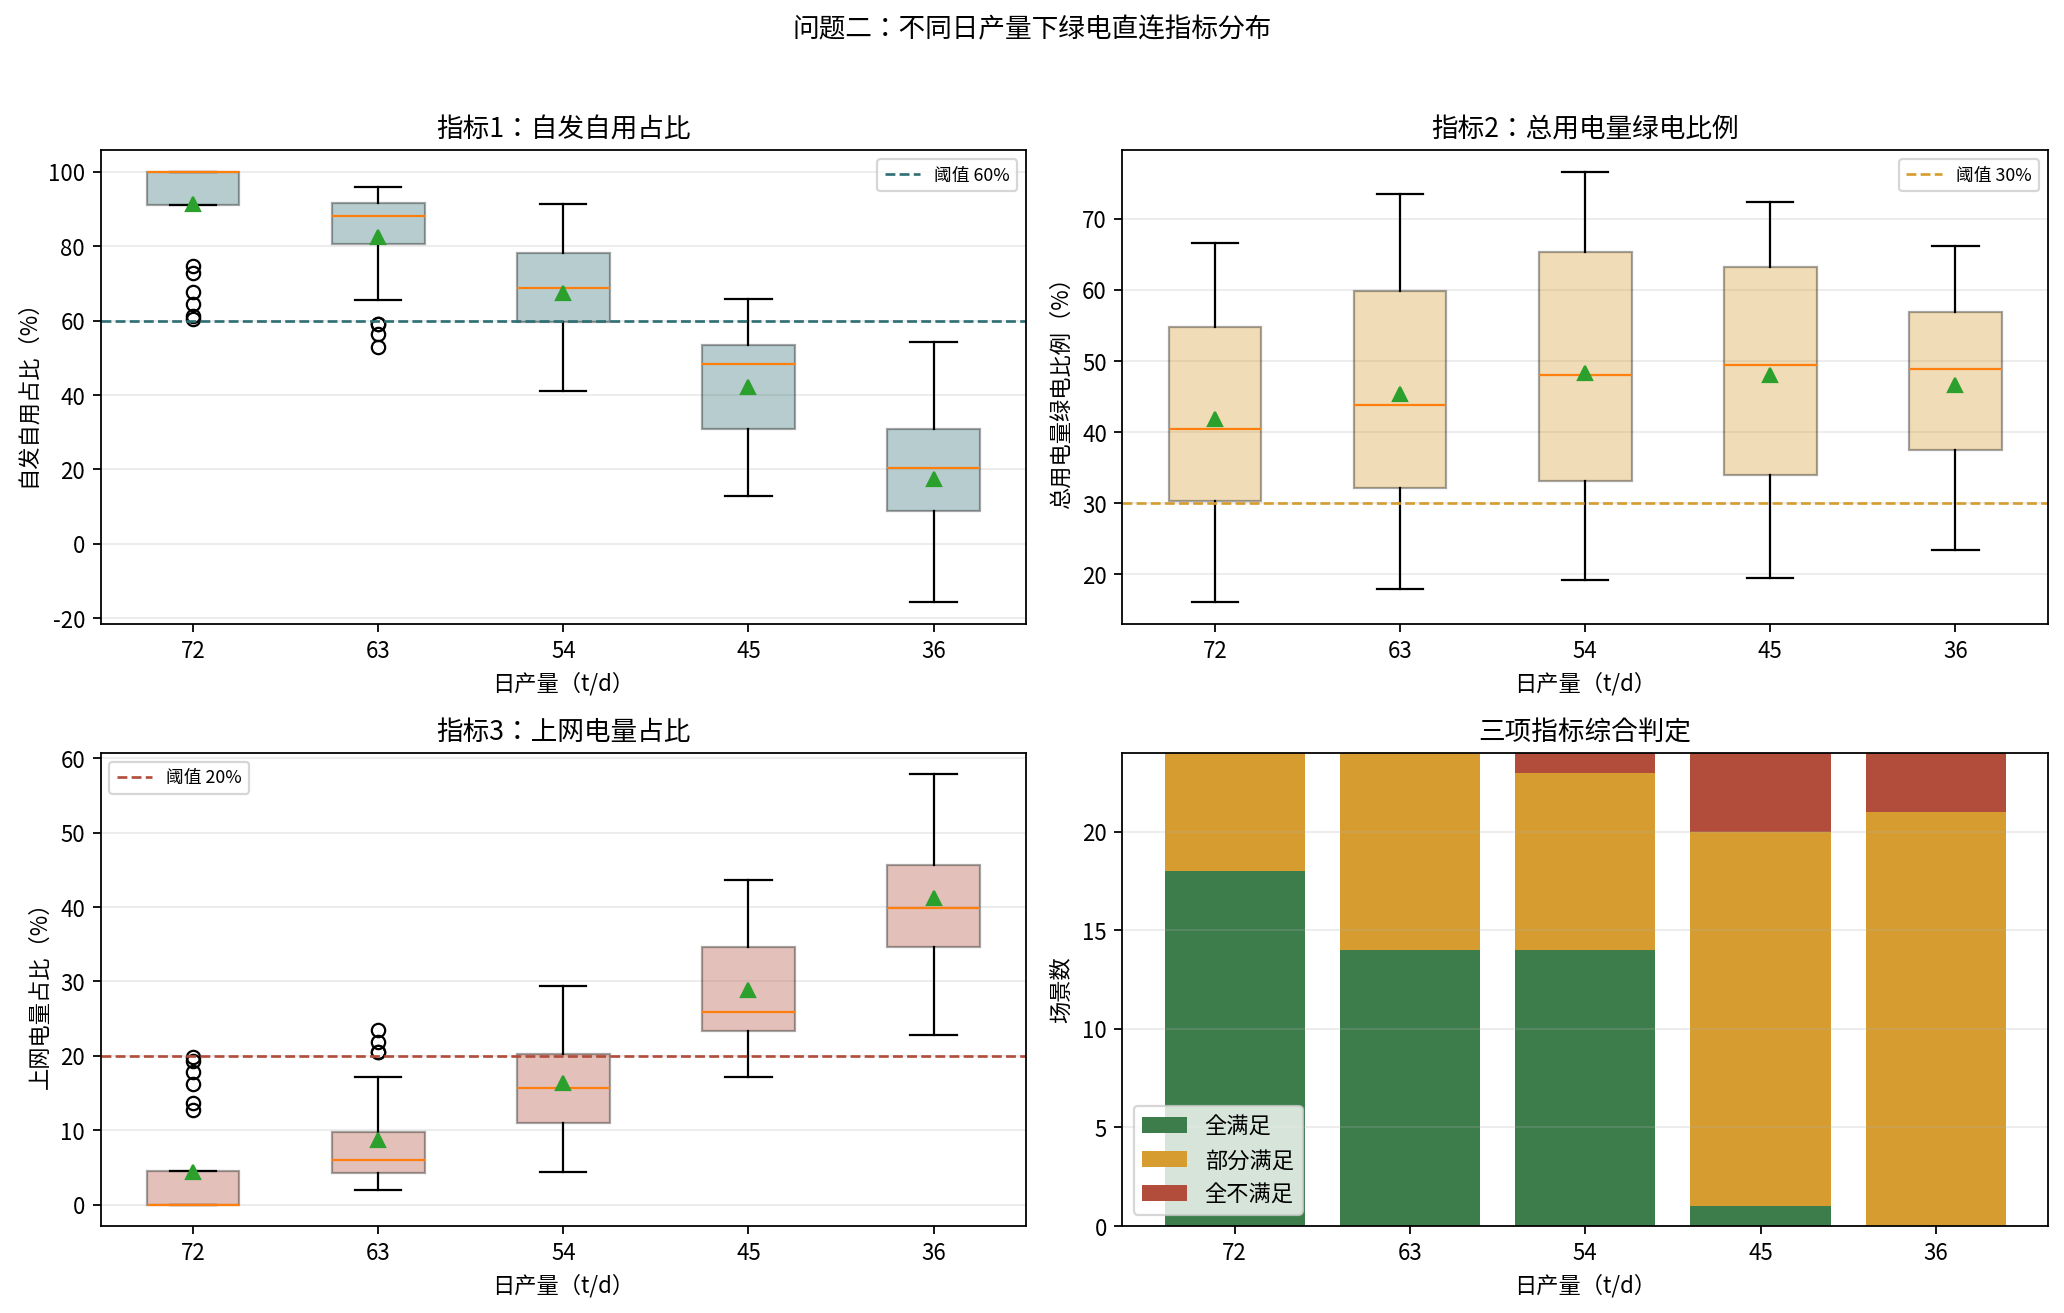

In [59]:
# 问题二（2）：绿电直连三项指标分布及综合判定。
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=160)
indicator_specs = [
    ('自发自用占比', '自发自用占比（%）', 60, '指标1：自发自用占比', '#2f6f73'),
    ('绿电比例', '总用电量绿电比例（%）', 30, '指标2：总用电量绿电比例', '#d69c2f'),
    ('上网比例', '上网电量占比（%）', 20, '指标3：上网电量占比', '#b14d3a'),
]
for ax, (col, ylabel, threshold, title, color) in zip(axes.flat[:3], indicator_specs):
    data = [q2_all_df.loc[q2_all_df['产量/t'] == p, col].values * 100 for p in PRODUCTIONS]
    bp = ax.boxplot(data, labels=[str(p) for p in PRODUCTIONS], showmeans=True, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.axhline(threshold, color=color, linestyle='--', linewidth=1.2, label=f'阈值 {threshold}%')
    ax.set_xlabel('日产量（t/d）')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

ax = axes.flat[3]
plot_order = PRODUCTIONS
x = np.arange(len(plot_order))
class_idx = q2_prod_class.set_index('产量/t').loc[plot_order]
bottom = np.zeros(len(plot_order))
colors = {'全满足': '#3c7d4b', '部分满足': '#d69c2f', '全不满足': '#b14d3a'}
for cls in ['全满足', '部分满足', '全不满足']:
    vals = class_idx[cls].values
    ax.bar(x, vals, bottom=bottom, label=cls, color=colors[cls])
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in plot_order])
ax.set_xlabel('日产量（t/d）')
ax.set_ylabel('场景数')
ax.set_title('三项指标综合判定')
ax.set_ylim(0, 24)
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.suptitle('问题二：不同日产量下绿电直连指标分布', y=1.02)
fig.tight_layout()
fig.savefig(OUT / 'q2_green_indicator_distribution.png', bbox_inches='tight')
plt.show()


In [60]:
# 问题二（2）：按箱线图1.5IQR规则识别离散点，并汇总为论文说明表。
q2_outlier_metrics = ['吨氨成本/元', '购电/MWh', '上网/MWh', '自发自用占比', '绿电比例', '上网比例']
outlier_rows = []
for p, group in q2_all_df.groupby('产量/t'):
    for metric in q2_outlier_metrics:
        q1 = group[metric].quantile(0.25)
        q3 = group[metric].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = group[(group[metric] < lower) | (group[metric] > upper)]
        for _, row in outliers.iterrows():
            outlier_rows.append({
                '产量/t': int(p),
                '场景': row['场景'],
                '异常指标': metric,
                '方向': '偏高' if row[metric] > upper else '偏低',
                '指标值': row[metric],
                '箱线图下界': lower,
                '箱线图上界': upper,
                '吨氨成本/元': row['吨氨成本/元'],
                '购电/MWh': row['购电/MWh'],
                '上网/MWh': row['上网/MWh'],
                '自发自用占比': row['自发自用占比'],
                '绿电比例': row['绿电比例'],
                '上网比例': row['上网比例'],
                '判定': row['判定'],
            })

q2_boxplot_outliers = pd.DataFrame(outlier_rows)
q2_boxplot_outliers.to_csv(OUT / 'q2_boxplot_outliers.csv', index=False, encoding='utf-8-sig')

q2_boxplot_outlier_summary = (
    q2_boxplot_outliers
    .groupby(['产量/t', '场景'])
    .agg(
        异常指标=('异常指标', lambda s: '；'.join(
            f'{metric}{direction}' for metric, direction in zip(s, q2_boxplot_outliers.loc[s.index, '方向'])
        )),
        吨氨成本=('吨氨成本/元', 'first'),
        购电=('购电/MWh', 'first'),
        上网=('上网/MWh', 'first'),
        自发自用=('自发自用占比', 'first'),
        绿电比例=('绿电比例', 'first'),
        上网比例=('上网比例', 'first'),
        判定=('判定', 'first'),
    )
    .reset_index()
)
q2_boxplot_outlier_summary.to_csv(OUT / 'q2_boxplot_outlier_summary.csv', index=False, encoding='utf-8-sig')
q2_boxplot_outlier_summary


,产量/t,场景,异常指标,吨氨成本,购电,上网,自发自用,绿电比例,上网比例,判定
0,45,W4P1,上网/MWh偏高,4228.797642,188.9542,382.6582,0.127272,0.723436,0.436364,部分满足
1,45,W5P1,上网/MWh偏高,4501.251055,212.7502,348.9502,0.148300,0.688607,0.425850,部分满足
2,54,W1P1,上网/MWh偏高,5138.049054,235.0722,189.1162,0.503478,0.708968,0.248261,部分满足
3,54,W3P1,上网/MWh偏高,5083.793933,229.8364,202.9564,0.480159,0.715450,0.259921,部分满足
4,54,W4P1,上网/MWh偏高,4673.211924,188.9542,258.1582,0.411219,0.766065,0.294391,部分满足
5,54,W5P1,上网/MWh偏高,4941.235785,222.3924,234.0924,0.428639,0.724666,0.285681,部分满足
6,54,W6P1,上网/MWh偏高,5378.269026,257.4304,165.4704,0.537637,0.681288,0.231181,部分满足
7,63,W1P1,上网/MWh偏高；自发自用占比偏低；上网比例偏高,5722.600665,326.6262,156.1702,0.589977,0.649625,0.205011,部分满足
8,63,W3P1,上网/MWh偏高；自发自用占比偏低；上网比例偏高,5639.317990,311.2944,159.9144,0.590404,0.666072,0.204798,部分满足
9,63,W4P1,上网/MWh偏高；自发自用占比偏低；上网比例偏高,5254.921254,246.8320,191.5360,0.563164,0.735221,0.218418,部分满足


In [61]:
q2_class = q2_df['判定'].value_counts().rename_axis('分类').reset_index(name='场景数')
q2_class['天数'] = q2_class['场景数'] * 15
q2_class['占比'] = q2_class['场景数'] / 24
annual_cost_q2 = (q2_df['吨氨成本/元'] * q2_df['产量/t'] * 15).sum() / (q2_df['产量/t'] * 15).sum()
annual_prod_q2 = (q2_df['产量/t'] * 15).sum()
q2_class, annual_prod_q2, annual_cost_q2

(     分类  场景数   天数     占比
 0  部分满足   21  315  0.875
 1  全不满足    3   45  0.125,
 np.int64(12960),
 np.float64(6685.603434649289))

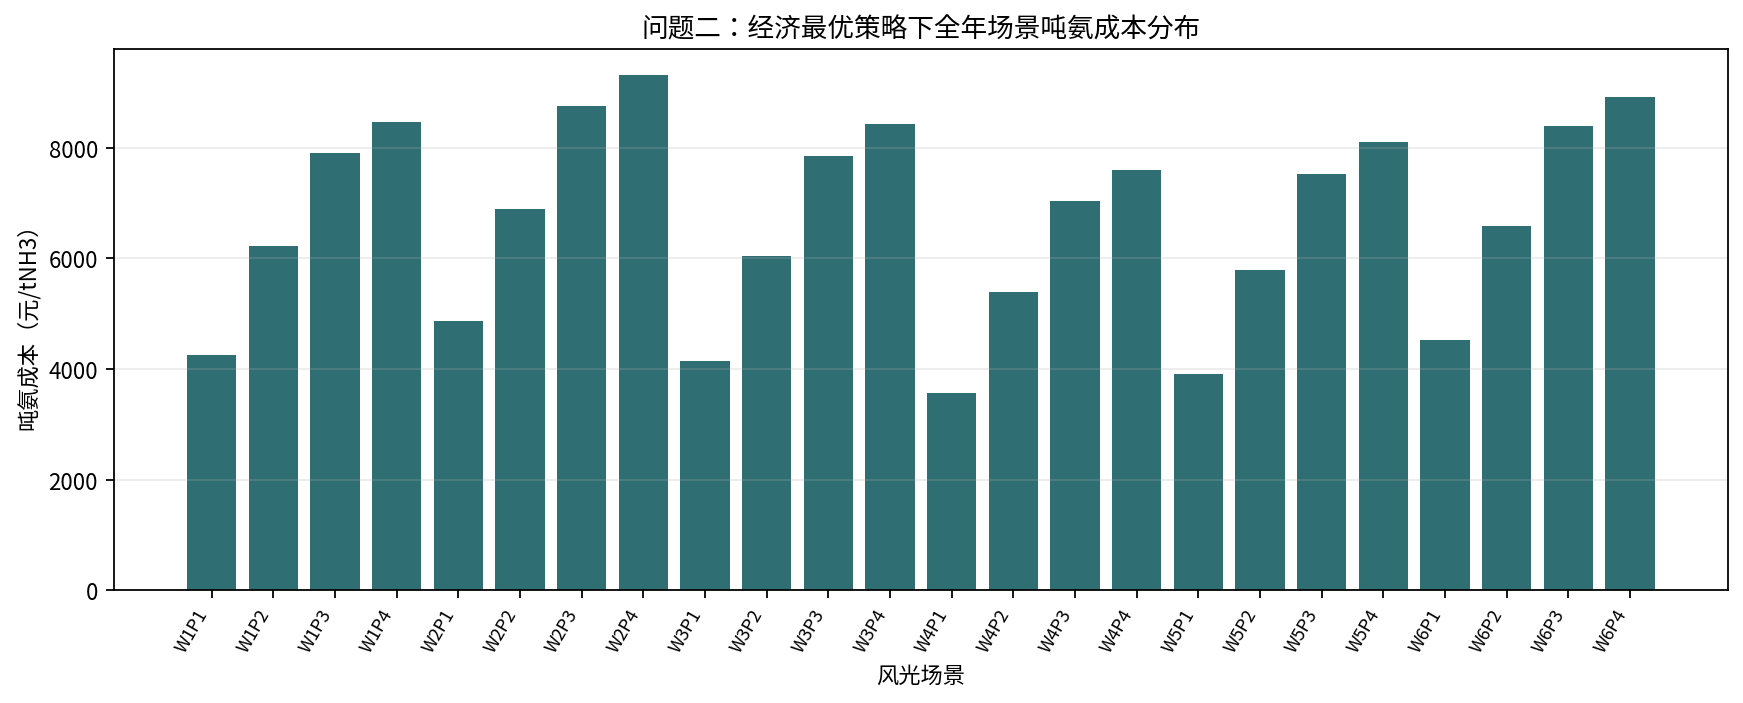

In [62]:
plt.figure(figsize=(11, 4.5), dpi=160)
plt.bar(np.arange(len(q2_df)), q2_df['吨氨成本/元'], color='#2f6f73')
plt.xticks(np.arange(len(q2_df)), q2_df['场景'], rotation=60, ha='right', fontsize=8)
plt.ylabel('吨氨成本（元/tNH3）')
plt.xlabel('风光场景')
plt.title('问题二：经济最优策略下全年场景吨氨成本分布')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / 'q2_best_cost_distribution.png')
plt.show()


## 5. 问题三：连续调节优化

因为谷电价低于上网电价，不能把购电和售电同时作为自由线性变量，否则会出现数学套利。这里用逐小时分段成本和步长 0.01 的动态规划求解。

In [63]:
def opt_continuous_dp(wind, pv, production, step=0.01):
    vals = np.arange(10, 101)  # y * 100, i.e. 0.10 to 1.00
    target = int(round(production / 3 * 100))
    inf = 1e15
    dp = np.full(target + 1, inf)
    dp[0] = 0
    prev = np.full((24, target + 1), -1, dtype=np.int16)

    for h in HOURS:
        new = np.full(target + 1, inf)
        choice = np.full(target + 1, -1, dtype=np.int16)
        re = wind[h] + pv[h]
        base = BASE_LOAD[h]
        costs = []
        for v in vals:
            y = v / 100
            demand = base + 41.5 * y
            costs.append(
                KWH_PER_MWH * (
                    tou_price[h] * max(demand - re, 0)
                    - FEED_IN_PRICE * max(re - demand, 0)
                    + (20 * y) * 0.1
                    + (20 * y) * 0.15
                    + (1.5 * y) * 0.002
                )
            )
        for v, c in zip(vals, costs):
            cand = dp[: target + 1 - v] + c
            better = cand < new[v:]
            idx = np.where(better)[0] + v
            new[idx] = cand[better]
            choice[idx] = v
        dp = new
        prev[h] = choice

    y_list = []
    s = target
    for h in range(23, -1, -1):
        v = prev[h, s]
        if v < 0:
            raise RuntimeError('No feasible DP solution')
        y_list.append(v / 100)
        s -= int(v)
    y = np.array(y_list[::-1])
    total_load = BASE_LOAD + 41.5 * y
    buy, sell, gen = split_buy_sell(total_load, wind, pv)
    ind = green_indicators(total_load, gen, buy, sell)
    cost = daily_cost_72(wind, pv, buy, sell, y)
    return y, ind, cost


typical_q3_rows = []
for p in PRODUCTIONS:
    y, ind, cost = opt_continuous_dp(WIND_CAP * wind_typ, PV_CAP * pv_typ, p)
    typical_q3_rows.append(row_from_result('typical', p, cost, ind))

typical_q3 = pd.DataFrame(typical_q3_rows)
typical_q3

,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定
0,typical,72,7315.029948,493.9522,40.6802,0.865174,0.532561,0.067413,全满足
1,typical,63,6574.636608,369.4522,40.6802,0.865174,0.603686,0.067413,全满足
2,typical,54,5992.070487,244.9522,40.6802,0.865174,0.696736,0.067413,全满足
3,typical,45,5762.059918,235.2722,155.5002,0.484628,0.655642,0.257686,部分满足
4,typical,36,5478.754064,235.2722,280.0002,0.071999,0.578909,0.464001,部分满足


In [64]:
def solve_all_scenarios_continuous():
    """Return full 5-production x 24-scenario table and per-scenario least-cost table."""
    all_rows = []
    detail = {}
    for iw in range(6):
        for ip in range(4):
            wind, pv = scenario_power(iw, ip)
            scenario_name = f'W{iw+1}P{ip+1}'
            candidates = []
            for p in PRODUCTIONS:
                y, ind, cost = opt_continuous_dp(wind, pv, p)
                row = row_from_result(scenario_name, p, cost, ind)
                row['平均负荷率'] = y.mean()
                row['最小负荷率'] = y.min()
                row['最大负荷率'] = y.max()
                all_rows.append(row)
                candidates.append((p, y, ind, cost, row))
            detail[scenario_name] = candidates

    all_df = pd.DataFrame(all_rows)
    best_idx = all_df.groupby('场景')['吨氨成本/元'].idxmin()
    best_df = all_df.loc[best_idx].sort_values('场景').reset_index(drop=True)
    return all_df, best_df, detail


q3_all_df, q3_best_df, q3_detail = solve_all_scenarios_continuous()
q3_df = q3_best_df
annual_cost_q3 = (q3_df['吨氨成本/元'] * q3_df['产量/t'] * 15).sum() / (q3_df['产量/t'] * 15).sum()
annual_prod_q3 = (q3_df['产量/t'] * 15).sum()
q3_best_df


,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定,平均负荷率,最小负荷率,最大负荷率
0,W1P1,36,4299.085164,238.9202,441.9642,-0.160370,0.572379,0.580185,部分满足,0.5,0.10,1.0
1,W1P2,36,6137.495830,253.0002,197.4842,0.215093,0.547179,0.392454,部分满足,0.5,0.10,1.0
2,W1P3,36,7324.982052,253.0002,31.7242,0.811974,0.547179,0.094013,全满足,0.5,0.10,1.0
3,W1P4,36,8001.955855,286.0984,0.1824,0.998663,0.487940,0.000669,全满足,0.5,0.10,1.0
4,W2P1,36,4985.930664,276.6322,376.8162,-0.143767,0.504882,0.571883,部分满足,0.5,0.10,1.0
5,W2P2,36,6824.341330,290.7122,132.3362,0.338888,0.479682,0.330556,部分满足,0.5,0.10,1.0
6,W2P3,36,8228.227527,324.4340,0.2980,0.997459,0.419326,0.001270,全满足,0.5,0.10,1.0
7,W2P4,36,9134.774497,388.9342,0.1582,0.998138,0.303884,0.000931,全满足,0.5,0.10,1.0
8,W3P1,36,4136.546708,223.3262,445.4462,-0.140941,0.600290,0.570471,部分满足,0.5,0.10,1.0
9,W3P2,36,5974.957375,237.4062,200.9662,0.230427,0.575089,0.384786,部分满足,0.5,0.10,1.0


In [65]:
# 问题三：完整保留“每种产量 × 24场景”的连续调节结果。
q3_all_df.to_csv(OUT / 'q3_all_productions_continuous.csv', index=False, encoding='utf-8-sig')
q3_best_df.to_csv(OUT / 'q3_best_by_scenario_continuous.csv', index=False, encoding='utf-8-sig')

q3_prod_summary = (
    q3_all_df
    .groupby('产量/t')
    .agg(
        场景数=('场景', 'count'),
        平均吨氨成本=('吨氨成本/元', 'mean'),
        最小吨氨成本=('吨氨成本/元', 'min'),
        最大吨氨成本=('吨氨成本/元', 'max'),
        平均购电量=('购电/MWh', 'mean'),
        平均上网量=('上网/MWh', 'mean'),
        平均自发自用占比=('自发自用占比', 'mean'),
        平均绿电比例=('绿电比例', 'mean'),
        平均上网比例=('上网比例', 'mean'),
    )
    .reset_index()
)
q3_prod_summary.to_csv(OUT / 'q3_by_production_summary.csv', index=False, encoding='utf-8-sig')

q3_prod_class = (
    q3_all_df
    .pivot_table(index='产量/t', columns='判定', values='场景', aggfunc='count', fill_value=0)
    .reset_index()
)
for col in ['全满足', '部分满足', '全不满足']:
    if col not in q3_prod_class.columns:
        q3_prod_class[col] = 0
q3_prod_class = q3_prod_class[['产量/t', '全满足', '部分满足', '全不满足']]
q3_prod_class.to_csv(OUT / 'q3_by_production_class_counts.csv', index=False, encoding='utf-8-sig')

q3_class = q3_df['判定'].value_counts().rename_axis('分类').reset_index(name='场景数')
q3_class['天数'] = q3_class['场景数'] * 15
q3_class['占比'] = q3_class['场景数'] / 24

q3_prod_summary, q3_prod_class, q3_class, annual_prod_q3, annual_cost_q3


(   产量/t  场景数       平均吨氨成本       最小吨氨成本        最大吨氨成本       平均购电量       平均上网量  平均自发自用占比    平均绿电比例    平均上网比例
 0    36   24  6402.150579  3565.772994   9134.774497  253.025025  170.280358  0.468274  0.547134  0.265863
 1    45   24  6763.631793  4231.675062   9321.826264  304.471875   97.227208  0.728420  0.554357  0.135790
 2    54   24  7126.469892  4675.609774   9569.668537  381.334758   49.590092  0.870797  0.527887  0.064601
 3    63   24  7666.027289  5138.020254  10026.506365  489.853300   33.608633  0.912381  0.474530  0.043810
 4    72   24  8278.560848  5986.190764  10369.134736  614.296658   33.551992  0.912556  0.418676  0.043722,
 判定  产量/t  全满足  部分满足  全不满足
 0     36   11    13     0
 1     45   16     8     0
 2     54   16     8     0
 3     63   20     4     0
 4     72   18     6     0,
      分类  场景数   天数        占比
 0  部分满足   13  195  0.541667
 1   全满足   11  165  0.458333,
 np.int64(12960),
 np.float64(6402.150579440956))

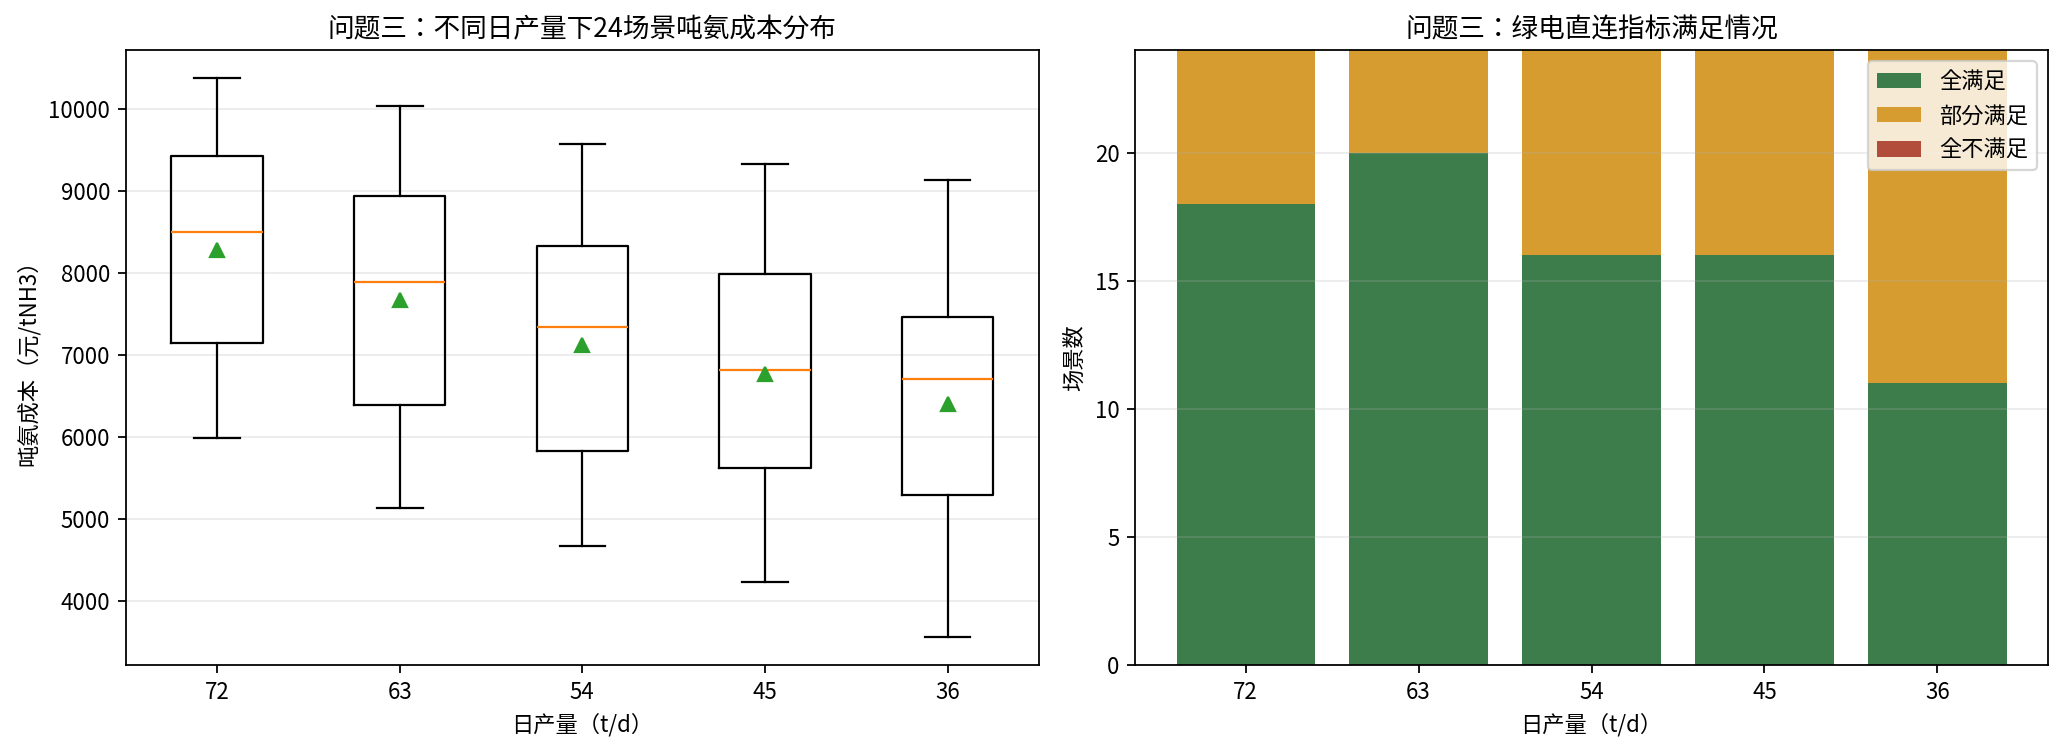

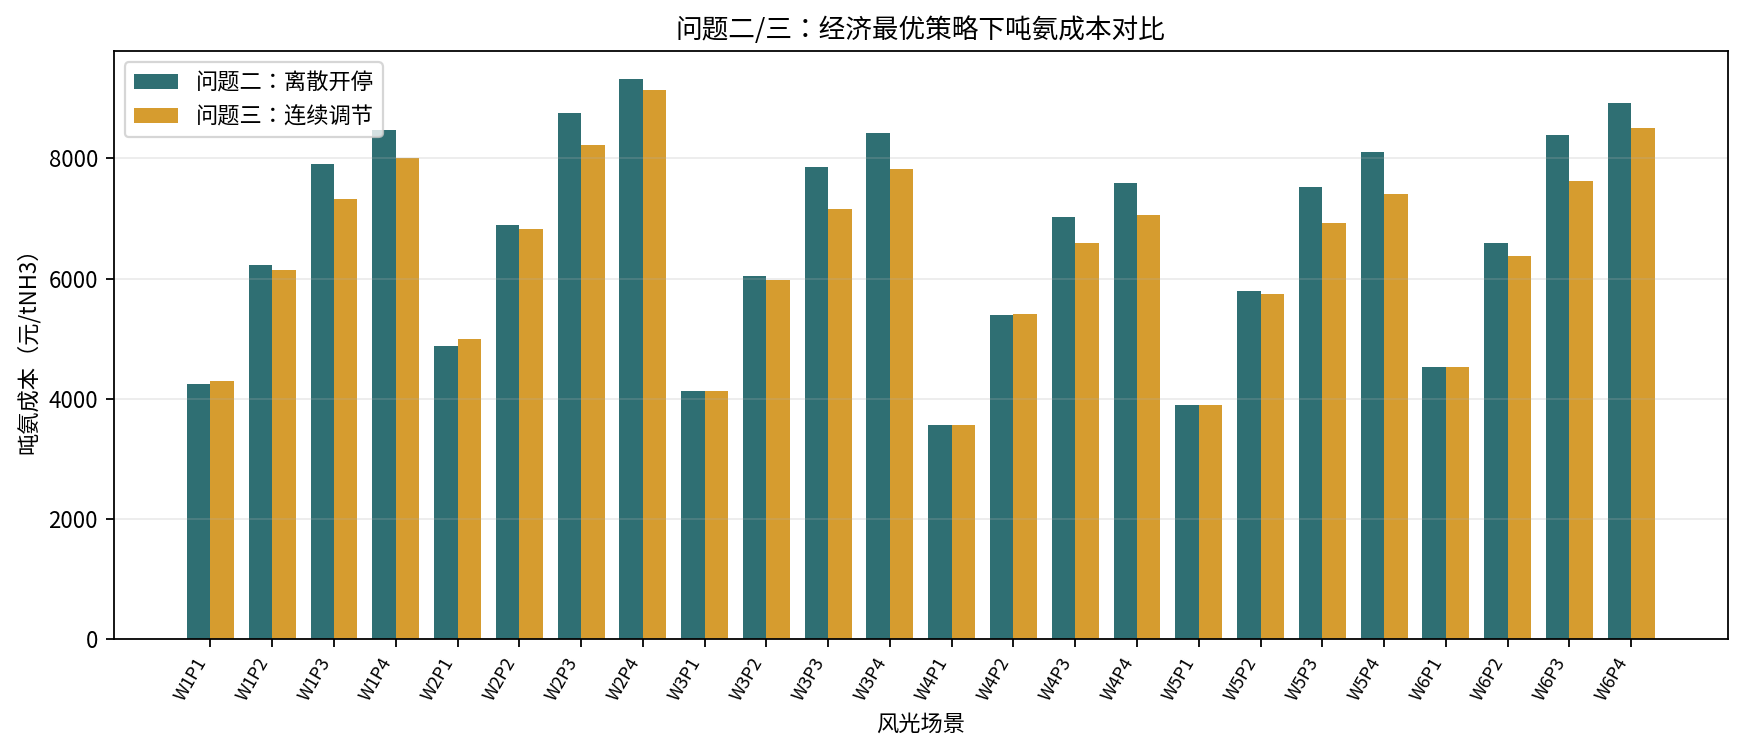

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=160)
plot_order = PRODUCTIONS
x = np.arange(len(plot_order))
box_data = [q3_all_df.loc[q3_all_df['产量/t'] == p, '吨氨成本/元'].values for p in plot_order]
axes[0].boxplot(box_data, labels=[str(p) for p in plot_order], showmeans=True)
axes[0].set_xlabel('日产量（t/d）')
axes[0].set_ylabel('吨氨成本（元/tNH3）')
axes[0].set_title('问题三：不同日产量下24场景吨氨成本分布')
axes[0].grid(axis='y', alpha=0.25)

class_idx = q3_prod_class.set_index('产量/t').loc[plot_order]
bottom = np.zeros(len(plot_order))
colors = {'全满足': '#3c7d4b', '部分满足': '#d69c2f', '全不满足': '#b14d3a'}
for cls in ['全满足', '部分满足', '全不满足']:
    vals = class_idx[cls].values
    axes[1].bar(x, vals, bottom=bottom, label=cls, color=colors[cls])
    bottom += vals
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(p) for p in plot_order])
axes[1].set_xlabel('日产量（t/d）')
axes[1].set_ylabel('场景数')
axes[1].set_ylim(0, 24)
axes[1].set_title('问题三：绿电直连指标满足情况')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / 'q3_by_production_cost_and_green_class.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=160)
x = np.arange(len(q2_df))
w = 0.38
ax.bar(x - w / 2, q2_df['吨氨成本/元'], width=w, label='问题二：离散开停', color='#2f6f73')
ax.bar(x + w / 2, q3_df['吨氨成本/元'], width=w, label='问题三：连续调节', color='#d69c2f')
ax.set_xticks(x)
ax.set_xticklabels(q2_df['场景'], rotation=60, ha='right', fontsize=8)
ax.set_xlabel('风光场景')
ax.set_ylabel('吨氨成本（元/tNH3）')
ax.set_title('问题二/三：经济最优策略下吨氨成本对比')
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'q2_q3_cost_distribution.png', bbox_inches='tight')
plt.show()


## 6. 问题四：离网和储能

In [67]:
def offgrid_no_storage(wind, pv):
    gen = wind + pv
    residual = gen - BASE_LOAD
    y = np.clip(residual / 41.5, 0, 1)
    curt = np.maximum(residual - 41.5 * y, 0).sum()
    base_deficit = np.maximum(-residual, 0).sum()
    production = 3 * y.sum()
    cost = (
        wind.sum() * KWH_PER_MWH * 0.15
        + pv.sum() * KWH_PER_MWH * 0.12
        + (20 * y).sum() * KWH_PER_MWH * 0.1
        + (20 * y).sum() * KWH_PER_MWH * 0.15
        + (1.5 * y).sum() * KWH_PER_MWH * 0.002
        + (72 * KG_PER_TON * H2_KG_PER_KG_NH3) * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    )
    return y, production, cost, curt, base_deficit


off_rows = []
off_detail = {}
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        y, production, cost, curt, deficit = offgrid_no_storage(wind, pv)
        name = f'W{iw+1}P{ip+1}'
        off_rows.append({
            '场景': name,
            '产量/t': production,
            '吨氨成本/元': cost / production,
            '弃电/MWh': curt,
            '常规负荷缺供/MWh': deficit,
        })
        off_detail[name] = (y, production, cost, curt, deficit)

off_df = pd.DataFrame(off_rows)
off_annual_prod = (off_df['产量/t'] * 15).sum()
off_annual_cost = (off_df['吨氨成本/元'] * off_df['产量/t'] * 15).sum() / off_annual_prod
off_df, off_annual_prod, off_annual_cost

(      场景       产量/t        吨氨成本/元        弃电/MWh  常规负荷缺供/MWh
 0   W1P1  40.895422   6017.432539  1.353240e+02      0.0000
 1   W1P2  31.448227   6337.510594  7.450200e+00      0.0000
 2   W1P3  20.004145   8014.706856  5.329071e-15      0.0000
 3   W1P4  15.331373   9443.245915  2.664535e-15      0.0000
 4   W2P1  36.774231   6085.339144  8.961200e+01      0.1382
 5   W2P2  24.561123   7018.778266  2.220446e-15      0.1382
 6   W2P3  12.578472  10535.047937  2.220446e-15      0.1382
 7   W2P4   7.905701  14795.067627  2.220446e-15      0.1382
 8   W3P1  42.921817   5878.739794  1.263682e+02      0.0000
 9   W3P2  33.096405   6191.412083  3.726400e+00      0.0000
 10  W3P3  21.383133   7739.205035  8.881784e-16      0.0000
 11  W3P4  16.710361   8972.817425  8.881784e-16      0.0000
 12  W4P1  46.445639   5869.557644  1.737060e+02      0.0000
 13  W4P2  39.607504   5811.636738  9.740200e+00      0.0000
 14  W4P3  28.328964   6759.314576  9.325873e-15      0.0000
 15  W4P4  23.656193   7

In [68]:
scale_need = []
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        re = wind + pv
        scale_need.extend(((BASE_LOAD + 41.5) / np.maximum(re, 1e-9)).tolist())

k_min = max(scale_need)
k_min, WIND_CAP * k_min, PV_CAP * k_min

(28.907640750670243, 1156.3056300268097, 1850.0890080428956)

In [69]:
ETA_C = 0.9
ETA_D = 0.9
LOSS = 0.002


def dispatch_storage_offgrid(wind, pv, ecap):
    n = 24
    gen = wind + pv
    # Variables: y, charge, discharge, soc, curtail, unserved_base.
    m = 6 * n
    c = np.zeros(m)
    c[:n] = -3
    c[5 * n:] = 10000

    aeq = []
    beq = []
    for h in range(n):
        row = np.zeros(m)
        row[h] = -41.5
        row[n + h] = -1
        row[2 * n + h] = 1
        row[4 * n + h] = -1
        row[5 * n + h] = 1
        aeq.append(row)
        beq.append(BASE_LOAD[h] - gen[h])

    for h in range(n):
        row = np.zeros(m)
        row[3 * n + h] = 1
        row[3 * n + (h - 1) % n] = -(1 - LOSS)
        row[n + h] = -ETA_C
        row[2 * n + h] = 1 / ETA_D
        aeq.append(row)
        beq.append(0)

    bounds = [(0, 1)] * n + [(0, None)] * n + [(0, None)] * n + [(0, ecap)] * n + [(0, None)] * n + [(0, None)] * n
    res = linprog(c, A_eq=np.array(aeq), b_eq=np.array(beq), bounds=bounds, method='highs')
    if not res.success:
        raise RuntimeError(res.message)

    x = res.x
    y = x[:n]
    charge = x[n:2 * n]
    discharge = x[2 * n:3 * n]
    soc = x[3 * n:4 * n]
    curtail = x[4 * n:5 * n]
    unserved = x[5 * n:6 * n]
    production = 3 * y.sum()
    throughput = charge.sum() + discharge.sum()
    cost = daily_cost_72(wind, pv, np.zeros(n), np.zeros(n), y, ecap=ecap, storage_throughput=throughput)
    return y, charge, discharge, soc, curtail, unserved, production, cost, throughput


max_curt_scenario = off_df.sort_values('弃电/MWh', ascending=False).iloc[0]['场景']
iw = int(max_curt_scenario[1]) - 1
ip = int(max_curt_scenario[3]) - 1
wind_max_curt, pv_max_curt = scenario_power(iw, ip)

storage_scan = []
for ecap in np.arange(0, 301, 1):
    out = dispatch_storage_offgrid(wind_max_curt, pv_max_curt, ecap)
    production = out[6]
    cost = out[7]
    curtail = out[4].sum()
    storage_scan.append({'储能/MWh': ecap, '产量/t': production, '吨氨成本/元': cost / production, '弃电/MWh': curtail})

storage_scan_df = pd.DataFrame(storage_scan)
best_storage = storage_scan_df.loc[storage_scan_df['吨氨成本/元'].idxmin()]
best_storage

储能/MWh     155.000000
产量/t        56.450642
吨氨成本/元    5681.635109
弃电/MWh       0.000000
Name: 155, dtype: float64

In [70]:
ecap_best = float(best_storage['储能/MWh'])
storage_rows = []
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        out = dispatch_storage_offgrid(wind, pv, ecap_best)
        production = out[6]
        cost = out[7]
        curtail = out[4].sum()
        storage_rows.append({
            '场景': f'W{iw+1}P{ip+1}',
            '产量/t': production,
            '吨氨成本/元': cost / production,
            '弃电/MWh': curtail,
        })

storage_df = pd.DataFrame(storage_rows)
storage_annual_prod = (storage_df['产量/t'] * 15).sum()
storage_annual_cost = (storage_df['吨氨成本/元'] * storage_df['产量/t'] * 15).sum() / storage_annual_prod
storage_df, storage_annual_prod, storage_annual_cost

(      场景       产量/t        吨氨成本/元  弃电/MWh
 0   W1P1  48.705707   5951.141550     0.0
 1   W1P2  31.883595   7165.903039     0.0
 2   W1P3  20.004145   9429.938693     0.0
 3   W1P4  15.331373  11289.819041     0.0
 4   W2P1  41.951075   6253.500095     0.0
 5   W2P2  24.548764   8174.833418     0.0
 6   W2P3  12.566114  12796.939071     0.0
 7   W2P4   7.893343  18402.643006     0.0
 8   W3P1  50.219048   5875.841729     0.0
 9   W3P2  33.314084   7013.681561     0.0
 10  W3P3  21.383133   9063.169250     0.0
 11  W3P4  16.710361  10667.005931     0.0
 12  W4P1  56.450642   5681.635109     0.0
 13  W4P2  40.174886   6462.171875     0.0
 14  W4P3  28.328964   7758.662891     0.0
 15  W4P4  23.656193   8633.910705     0.0
 16  W5P1  52.521968   5812.519620     0.0
 17  W5P2  36.017291   6776.191080     0.0
 18  W5P3  24.172048   8449.301825     0.0
 19  W5P4  19.499277   9676.641102     0.0
 20  W6P1  46.038482   6032.063270     0.0
 21  W6P2  28.661205   7538.606599     0.0
 22  W6P3  

In [71]:
# 问题四（3）：以离网+储能各场景产量作为相同需求，计算联网连续调节对照成本。
grid_same_rows = []
for _, srow in storage_df.iterrows():
    name = srow['场景']
    iw = int(name[1]) - 1
    ip = int(name[3]) - 1
    wind, pv = scenario_power(iw, ip)
    target_prod = float(srow['产量/t'])
    y, ind, cost = opt_continuous_dp(wind, pv, target_prod)
    actual_prod = 3 * y.sum()
    grid_same_rows.append({
        '场景': name,
        '目标产量/t': target_prod,
        '联网实际产量/t': actual_prod,
        '离网储能吨氨成本/元': float(srow['吨氨成本/元']),
        '联网同产量吨氨成本/元': cost / actual_prod,
        '购电/MWh': ind['购电/MWh'],
        '上网/MWh': ind['上网/MWh'],
        '自发自用占比': ind['自发自用占比'],
        '绿电比例': ind['绿电比例'],
        '上网比例': ind['上网比例'],
        '判定': classify(ind),
    })

grid_same_storage_df = pd.DataFrame(grid_same_rows)
grid_same_storage_df.to_csv(OUT / 'q4_grid_connected_same_storage_production.csv', index=False, encoding='utf-8-sig')
grid_same_annual_prod = (grid_same_storage_df['联网实际产量/t'] * 15).sum()
grid_same_annual_cost = (
    grid_same_storage_df['联网同产量吨氨成本/元'] * grid_same_storage_df['联网实际产量/t'] * 15
).sum() / grid_same_annual_prod

grid_same_storage_df, grid_same_annual_prod, grid_same_annual_cost


(      场景     目标产量/t  联网实际产量/t    离网储能吨氨成本/元   联网同产量吨氨成本/元    购电/MWh    上网/MWh    自发自用占比      绿电比例      上网比例    判定
 0   W1P1  48.705707     48.72   5951.141550   4976.910301  238.9202  266.0042  0.301610  0.674797  0.349195  部分满足
 1   W1P2  31.883595     31.89   7165.903039   6039.831778  253.0002  254.3392 -0.010879  0.495880  0.505440  部分满足
 2   W1P3  20.004145     20.01   9429.938693   7825.731084  164.2930  164.2120  0.026730  0.513242  0.486635  部分满足
 3   W1P4  15.331373     15.33  11289.819041   9338.851695  114.2020  114.2210  0.162615  0.581348  0.418693  部分满足
 4   W2P1  41.951075     41.94   6253.500095   5256.354003  276.6322  294.6462  0.105648  0.568362  0.447176  部分满足
 5   W2P2  24.548764     24.54   8174.833418   6868.990786  236.9462  237.1002 -0.184482  0.407916  0.592241  部分满足
 6   W2P3  12.566114     12.57  12796.939071  10663.905258   90.1528   90.1318  0.231561  0.615725  0.384220  部分满足
 7   W2P4   7.893343      7.89  18402.643006  15894.697096   40.7088   40.7878  

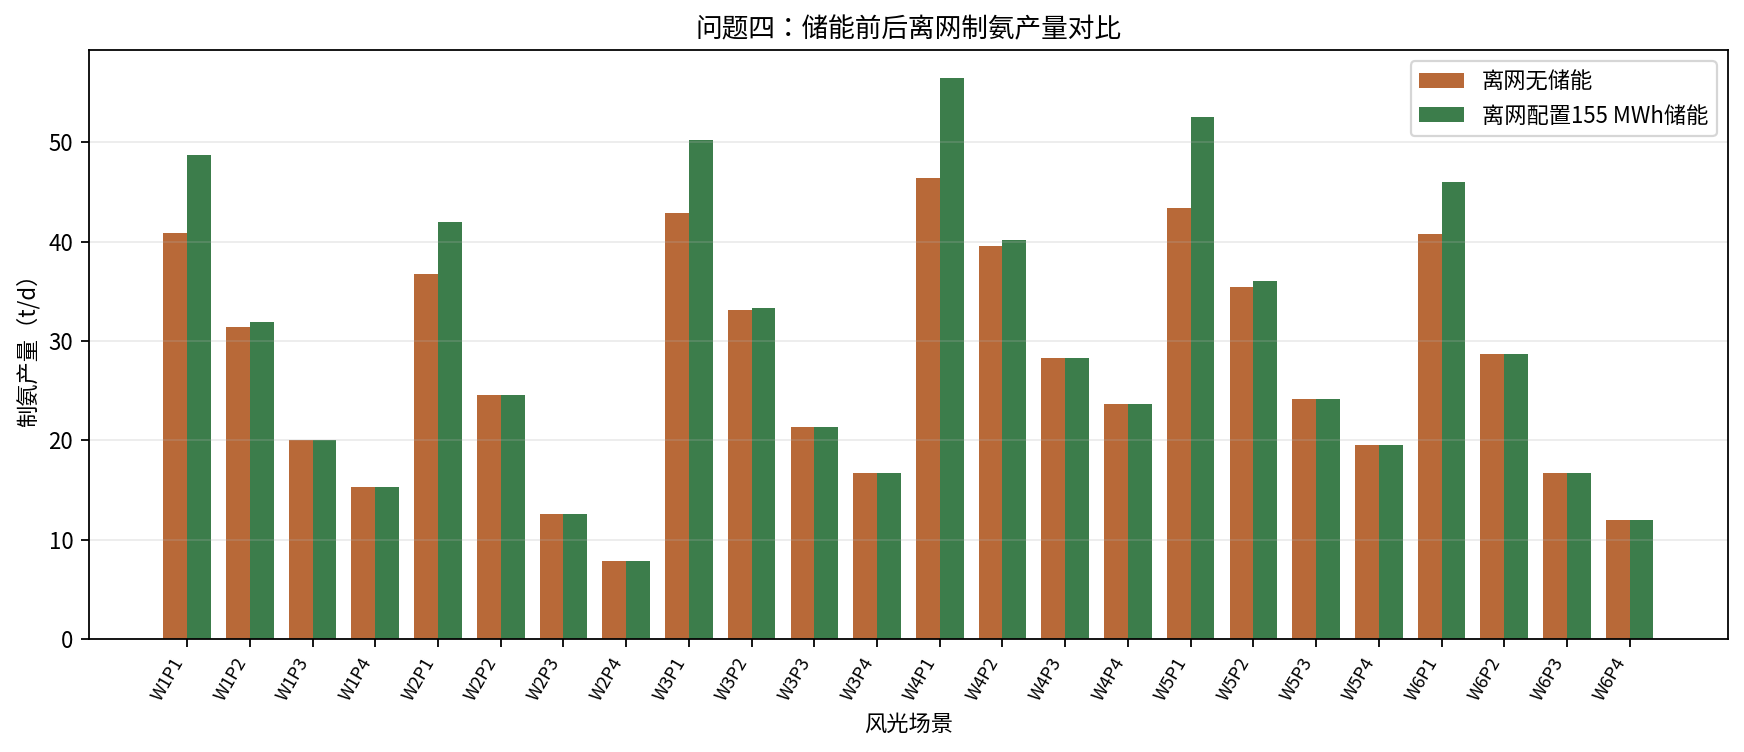

In [72]:
plot_df = off_df[['场景', '产量/t']].rename(columns={'产量/t': '无储能'})
plot_df['有储能'] = storage_df['产量/t']

x = np.arange(len(plot_df))
w = 0.38
plt.figure(figsize=(11, 4.8), dpi=160)
plt.bar(x - w / 2, plot_df['无储能'], width=w, label='离网无储能', color='#b86938')
plt.bar(x + w / 2, plot_df['有储能'], width=w, label=f'离网配置{ecap_best:.0f} MWh储能', color='#3c7d4b')
plt.xticks(x, plot_df['场景'], rotation=60, ha='right', fontsize=8)
plt.ylabel('制氨产量（t/d）')
plt.xlabel('风光场景')
plt.title('问题四：储能前后离网制氨产量对比')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'q4_production_compare.png')
plt.show()


## 7. 汇总

In [73]:
summary = pd.DataFrame([
    {'模式': '并网-问题二离散', '年产量/t': annual_prod_q2, '平均吨氨成本/元': annual_cost_q2, '产能利用率': annual_prod_q2 / (72 * 360)},
    {'模式': '并网-问题三连续', '年产量/t': annual_prod_q3, '平均吨氨成本/元': annual_cost_q3, '产能利用率': annual_prod_q3 / (72 * 360)},
    {'模式': '离网-无储能', '年产量/t': off_annual_prod, '平均吨氨成本/元': off_annual_cost, '产能利用率': off_annual_prod / (72 * 360)},
    {'模式': f'离网-{ecap_best:.0f}MWh储能', '年产量/t': storage_annual_prod, '平均吨氨成本/元': storage_annual_cost, '产能利用率': storage_annual_prod / (72 * 360)},
    {'模式': '并网-同离网储能产量', '年产量/t': grid_same_annual_prod, '平均吨氨成本/元': grid_same_annual_cost, '产能利用率': grid_same_annual_prod / (72 * 360)},
])
summary


,模式,年产量/t,平均吨氨成本/元,产能利用率
0,并网-问题二离散,12960.000000,6685.603435,0.500000
1,并网-问题三连续,12960.000000,6402.150579,0.500000
2,离网-无储能,9934.083976,6879.034275,0.383259
3,离网-155MWh储能,10630.740538,7516.679614,0.410137
4,并网-同离网储能产量,10631.250000,6285.003661,0.410156
